# NN-kNN Classification Workflow

This notebook uses the maintained IJCAI-26 NN-kNN core for classification. Retrieval, feature weighting, case scoring, and case normalization remain the current model; the output layer sums normalized case activation into class probability mass and trains it with negative log likelihood.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from model.classification_workflow import (
    list_supported_classification_datasets,
    list_supported_classification_benchmark_methods,
    make_classification_cfg,
    run_single_nnknn_classification_experiment,
    run_repeated_classification_model_benchmarks,
)

print(list_supported_classification_datasets())
print(list_supported_classification_benchmark_methods())

{'small': ['iris', 'zebra', 'zebra_special', 'wine', 'breast_cancer', 'balance', 'digits'], 'image': ['mnist', 'cifar10', 'svhn']}
{'small': ['nnknn', 'knn', 'mlp'], 'image': ['nnknn_conv_trainable', 'nnknn_conv_frozen', 'convnet', 'knn_pixels', 'knn_conv_frozen']}


## Small Dataset Sanity Check

The IJCAI-25 small-data family is available as `iris`, `zebra`, `zebra_special`, `wine`, `breast_cancer`, `balance`, and `digits`. Standardization is fitted on the training split only.

In [2]:
cfg = make_classification_cfg({
    "training_epochs": 70,
    "batch_size": 32,
    "patience": 20,
    "case_normalizer": "softmax",  # Change to "sparsemax" for sparse case activation.
    "top_k": 5,
    "explanation_mode": True,
    "checkpoint_path": "checkpoints/nnknn_classification_notebook.pth",
})

result = run_single_nnknn_classification_experiment(
    "zebra", cfg, run_seed=42, split_seed=42, checkpoint_label="iris_demo"
)
print("Validation accuracy:", result["accuracy"])
print("Auto-standardized features:", result["standardized_features"])
print("First class probability masses:", result["class_probabilities"][:3])

cases trainable: False
labels trainable: False
Number of feature extractor parameters: 0
Number of glocal weightor parameters: 1
torch.Size([4, 4])
Number of adapter parameters: 0
Number of case_net_params: 3
torch.Size([120])
torch.Size([120])
torch.Size([120, 4])
*****************
Training started for training_epochs epochs with batch size 32

[Stage 1] Retrieval-only training for up to 70 epochs (patience=30)
[Stage1] Epoch 1 - Val Acc: 0.9667 | Val Loss: 0.0678
[Stage1] New best (epoch 1) Val Metric: 0.9667 | Val Loss: 0.0678 — saved: checkpoints/nnknn_classification_notebook_iris_iris_demo_retr.pth
[Stage1] Epoch 2 - Val Acc: 1.0000 | Val Loss: 0.0547
[Stage1] New best (epoch 2) Val Metric: 1.0000 | Val Loss: 0.0547 — saved: checkpoints/nnknn_classification_notebook_iris_iris_demo_retr.pth
[Stage1] Epoch 3 - Val Acc: 1.0000 | Val Loss: 0.0374
[Stage1] New best (epoch 3) Val Metric: 1.0000 | Val Loss: 0.0374 — saved: checkpoints/nnknn_classification_notebook_iris_iris_demo_retr.pth

In [3]:
# Explanation output uses cases retrieved by the current model.
print("Top retrieved class ids for query 0:", result["most_activated_class_ids"][0])
print("Top retrieved activation mass for query 0:", result["most_activated_activations"][0])

Top retrieved class ids for query 0: tensor([0, 0, 0, 0, 0])
Top retrieved activation mass for query 0: tensor([0.2110, 0.2012, 0.1983, 0.1970, 0.1925])


In [4]:
import numpy as np
from ipywidgets import interact, IntSlider

import matplotlib.pyplot as plt

def plot_query_with_cases(query_idx):
    """Plot a single query and its top-k activated cases on 2D scatter plot."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Get all training data
    X_train = result["X_train"].numpy()
    y_train = result["y_train"].numpy()
    
    # Plot all training cases, color-coded by class
    colors = ['blue', 'red']
    for class_id in range(result["num_classes"]):
        mask = y_train == class_id
        ax.scatter(X_train[mask, 0], X_train[mask, 1], 
                  c=colors[class_id], label=f'Class {class_id}', 
                  alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
    
    # Get query point
    query_point = result["X_val"][query_idx].numpy()
    ax.scatter(query_point[0], query_point[1], 
              c='green', marker='*', s=500, label='Query', 
              edgecolors='black', linewidth=1.5, zorder=5)
    
    # Get top-k activated cases and their activations
    top_cases = result["most_activated_cases"][query_idx].numpy()
    top_class_ids = result["most_activated_class_ids"][query_idx].numpy()
    top_activations = result["most_activated_activations"][query_idx].numpy()
    
    # Plot top-k cases with size proportional to activation
    for k, (case, class_id, activation) in enumerate(zip(top_cases, top_class_ids, top_activations)):
        size = 200 * activation  # Scale size by activation strength
        ax.scatter(case[0], case[1], c=colors[class_id], marker='s', 
                  s=size, alpha=0.7, edgecolors='gold', linewidth=2, 
                  label=f'Top-{k+1} (act={activation:.3f})', zorder=4)
    
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Query {query_idx} - Predicted Class: {result["predictions"][query_idx].item()}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(plot_query_with_cases, query_idx=IntSlider(min=0, max=10, step=1, value=0))

interactive(children=(IntSlider(value=0, description='query_idx', max=10), Output()), _dom_classes=('widget-in…

<function __main__.plot_query_with_cases(query_idx)>

In [5]:
glocal = result.get("glocal_weightor", result["model"].glocal_weightor)

if hasattr(glocal, "state_dict"):
    for name, value in glocal.state_dict().items():
        print(f"{name}: {value}")
elif hasattr(glocal, "weights"):
    print("weights:", glocal.weights)
else:
    print(glocal)

feature_weights: tensor([[1.0977, 0.9044]], device='cuda:0')


## Representative Benchmark Check

This short run checks that NN-kNN, kNN, and a four-hidden-layer MLP execute on shared stratified folds. Use more folds and epochs for a table intended for reporting.

In [4]:
summary, runs, _ = run_repeated_classification_model_benchmarks(
    "zebra_special",
    cfg,
    methods=["nnknn", "knn", "mlp"],
    num_runs=3,
    mode="kfold",
    base_seed=42,
    method_cfgs={"mlp": {"epochs": 50, "patience": 10}},
)
summary

[classification benchmark] zebra_special method=nnknn
cases trainable: False
labels trainable: False
Number of feature extractor parameters: 0
Number of glocal weightor parameters: 1
torch.Size([4, 2])
Number of adapter parameters: 0
Number of case_net_params: 3
torch.Size([146])
torch.Size([146])
torch.Size([146, 4])
*****************
Training started for training_epochs epochs with batch size 32

[Stage 1] Retrieval-only training for up to 70 epochs (patience=30)
[Stage1] Epoch 1 - Val Acc: 0.7162 | Val Loss: 2.3718
[Stage1] New best (epoch 1) Val Metric: 0.7162 | Val Loss: 2.3718 — saved: checkpoints/nnknn_classification_notebook_zebra_special_kfold_1_nnknn_retr.pth
[Stage1] Epoch 2 - Val Acc: 0.7162 | Val Loss: 2.5373
[Stage1] No improv. Best so far: 2.3718 (epoch 1)
[Stage1] Epoch 3 - Val Acc: 0.6892 | Val Loss: 2.4728
[Stage1] No improv. Best so far: 2.3718 (epoch 1)
[Stage1] Epoch 4 - Val Acc: 0.6892 | Val Loss: 2.5183
[Stage1] No improv. Best so far: 2.3718 (epoch 1)
[Stage1] E

,dataset,mode,method,num_runs,accuracy_mean,accuracy_std,accuracy_table
0,zebra_special,kfold,nnknn,3,0.913551,0.057182,0.9136 +/- 0.0572
1,zebra_special,kfold,knn,3,0.340738,0.047280,0.3407 +/- 0.0473
2,zebra_special,kfold,mlp,3,0.550105,0.024230,0.5501 +/- 0.0242


## Image Workflow

For `mnist`, `cifar10`, or `svhn`, the loader uses the official train/test split and fits normalization statistics on training images. Training reserves an inner validation slice for checkpoint selection and reports on official test data. Start with a subset before a full image benchmark.

In [5]:
run_image_demo = False
if run_image_demo:
    image_cfg = make_classification_cfg({
        "training_epochs": 5,
        "batch_size": 64,
        "top_k": 5,
        "explanation_mode": True,
        "checkpoint_path": "checkpoints/nnknn_mnist_subset.pth",
    })
    image_result = run_single_nnknn_classification_experiment(
        "mnist",
        image_cfg,
        dataset_kwargs={"max_train_samples": 1000, "max_eval_samples": 300},
        checkpoint_label="mnist_subset",
    )
    print("MNIST subset accuracy:", image_result["accuracy"])

For image baseline comparisons, call `run_repeated_classification_model_benchmarks` with methods `convnet`, `knn_pixels`, `knn_conv_frozen`, `nnknn_conv_trainable`, and `nnknn_conv_frozen`. The frozen NN-kNN method reuses a trained ConvNet feature extractor and keeps it frozen during NN-kNN training.

cases trainable: False
labels trainable: False
Number of feature extractor parameters: 0
Number of glocal weightor parameters: 1
torch.Size([4, 2])
Number of adapter parameters: 0
Number of case_net_params: 3
torch.Size([88])
torch.Size([88])
torch.Size([88, 4])
*****************
Training started for training_epochs epochs with batch size 32

[Stage 1] Retrieval-only training for up to 70 epochs (patience=30)
[Stage1] Epoch 1 - Val Acc: 0.7273 | Val Loss: 1.4829
[Stage1] New best (epoch 1) Val Metric: 0.7273 | Val Loss: 1.4829 — saved: checkpoints/nnknn_classification_notebook_zebra_zebra_inspection_retr.pth
[Stage1] Epoch 2 - Val Acc: 0.7273 | Val Loss: 1.4767
[Stage1] New best (epoch 2) Val Metric: 0.7273 | Val Loss: 1.4767 — saved: checkpoints/nnknn_classification_notebook_zebra_zebra_inspection_retr.pth
[Stage1] Epoch 3 - Val Acc: 0.6818 | Val Loss: 2.0775
[Stage1] No improv. Best so far: 1.4767 (epoch 2)
[Stage1] Epoch 4 - Val Acc: 0.6818 | Val Loss: 2.0681
[Stage1] No improv. Bes

,row_id,true_class,predicted_class,confidence,correct,p_class_0,p_class_1
0,17,1,0,0.5530,False,0.5530,0.4470
1,75,1,1,1.0000,True,0.0000,1.0000
2,24,0,0,1.0000,True,1.0000,0.0000
3,109,0,0,1.0000,True,1.0000,0.0000
4,20,0,0,1.0000,True,1.0000,0.0000
5,7,0,0,1.0000,True,1.0000,0.0000
6,33,1,1,1.0000,True,0.0000,1.0000
7,101,0,0,0.9999,True,0.9999,0.0001
8,13,1,1,0.9998,True,0.0002,0.9998
9,28,0,0,0.9997,True,0.9997,0.0003


predicted,0,1
true,,
0,12,0
1,1,9


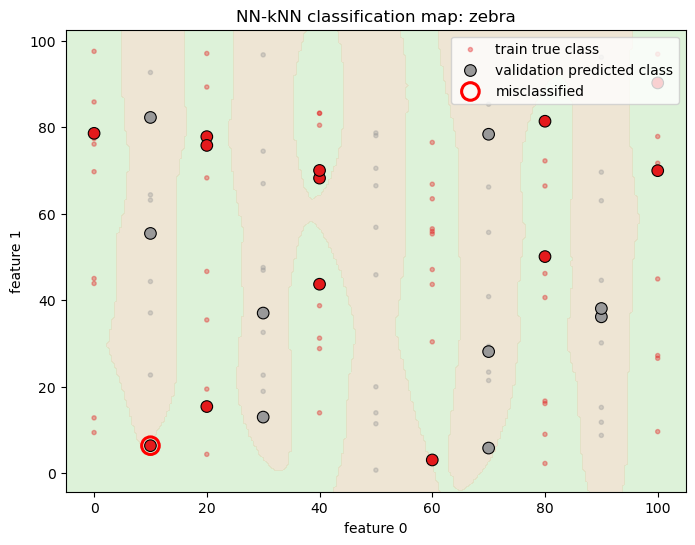

Validation position 20, original row 17: true=1, predicted=0
Retrieved class ids: [0, 1, 1, 0, 1]
Retrieved activation mass: [0.5063999891281128, 0.3763999938964844, 0.06369999796152115, 0.04659999907016754, 0.006899999920278788]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

inspection_dataset = "zebra"  # Change to "zebra_special" to inspect that variant.
zebra_result = run_single_nnknn_classification_experiment(
    inspection_dataset,
    cfg,
    run_seed=42,
    split_seed=42,
    checkpoint_label=f"{inspection_dataset}_inspection",
)

zebra_probs = zebra_result["class_probabilities"].detach().cpu()
zebra_pred = zebra_result["predictions"].detach().cpu()
zebra_true = zebra_result["y_val"].detach().cpu()
zebra_confidence, _ = zebra_probs.max(dim=1)

zebra_view = pd.DataFrame(
    {
        "row_id": zebra_result["val_idx"].detach().cpu().numpy(),
        "true_class": zebra_true.numpy(),
        "predicted_class": zebra_pred.numpy(),
        "confidence": zebra_confidence.numpy().round(4),
        "correct": (zebra_pred == zebra_true).numpy(),
    }
)
for class_idx in range(zebra_probs.shape[1]):
    zebra_view[f"p_class_{class_idx}"] = zebra_probs[:, class_idx].numpy().round(4)

print("Accuracy:", zebra_result["accuracy"])
print("Auto-standardized features:", zebra_result["standardized_features"])
display(
    zebra_view.sort_values(["correct", "confidence"], ascending=[True, False])
    .reset_index(drop=True)
)
display(
    pd.crosstab(
        zebra_view["true_class"],
        zebra_view["predicted_class"],
        rownames=["true"],
        colnames=["predicted"],
        dropna=False,
    )
)

raw_X = zebra_result["X"].detach().cpu().numpy()
train_X = zebra_result["X_train_raw"].detach().cpu().numpy()
val_X = zebra_result["X_val_raw"].detach().cpu().numpy()
train_y = zebra_result["y_train"].detach().cpu().numpy()
correct_mask = (zebra_pred == zebra_true).numpy()

x_min, x_max = raw_X[:, 0].min() - 5, raw_X[:, 0].max() + 5
y_min, y_max = raw_X[:, 1].min() - 5, raw_X[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
grid_features = zebra_result["scaler"].transform(grid_raw) if zebra_result["scaler"] is not None else grid_raw

model = zebra_result["model"]
device = next(model.parameters()).device
model.eval()
grid_predictions = []
with torch.no_grad():
    for start in range(0, len(grid_features), 2048):
        grid_tensor = torch.tensor(grid_features[start : start + 2048], dtype=torch.float32, device=device)
        _, predicted_grid, *_ = model(grid_tensor)
        grid_predictions.append(predicted_grid.detach().cpu())
grid_predictions = torch.cat(grid_predictions).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, grid_predictions, levels=np.arange(zebra_probs.shape[1] + 1) - 0.5, cmap="Pastel1", alpha=0.65)
ax.scatter(train_X[:, 0], train_X[:, 1], c=train_y, cmap="Set1", marker=".", alpha=0.35, label="train true class")
ax.scatter(
    val_X[:, 0],
    val_X[:, 1],
    c=zebra_pred.numpy(),
    cmap="Set1",
    edgecolor="black",
    linewidth=0.8,
    s=70,
    label="validation predicted class",
)
ax.scatter(
    val_X[~correct_mask, 0],
    val_X[~correct_mask, 1],
    facecolors="none",
    edgecolors="red",
    linewidth=2.2,
    s=160,
    label="misclassified",
)
ax.set_title(f"NN-kNN classification map: {inspection_dataset}")
ax.set_xlabel("feature 0")
ax.set_ylabel("feature 1")
ax.legend(loc="upper right")
plt.show()

if "most_activated_class_ids" in zebra_result:
    missed_positions = zebra_view.index[~zebra_view["correct"]].tolist()[:5]
    retrieved_classes = zebra_result["most_activated_class_ids"].detach().cpu().numpy()
    retrieved_activations = zebra_result["most_activated_activations"].detach().cpu().numpy()
    for pos in missed_positions:
        print(
            f"Validation position {pos}, original row {zebra_view.loc[pos, 'row_id']}: "
            f"true={zebra_view.loc[pos, 'true_class']}, "
            f"predicted={zebra_view.loc[pos, 'predicted_class']}"
        )
        print("Retrieved class ids:", retrieved_classes[pos].tolist())
        print("Retrieved activation mass:", retrieved_activations[pos].round(4).tolist())

In [7]:
zebra_all = pd.DataFrame(
    {
        "row_id": np.arange(len(raw_X)),
        "feature_0": raw_X[:, 0],
        "feature_1": raw_X[:, 1],
        "true_class": zebra_result["y"].detach().cpu().numpy(),
    }
)

zebra_validation_details = zebra_view[
    ["row_id", "predicted_class", "confidence", "correct"]
    + [column for column in zebra_view.columns if column.startswith("p_class_")]
]
zebra_all = zebra_all.merge(zebra_validation_details, on="row_id", how="left")
zebra_all["split"] = np.where(zebra_all["predicted_class"].notna(), "validation", "train")

ordered_columns = [
    "row_id",
    "split",
    "feature_0",
    "feature_1",
    "true_class",
    "predicted_class",
    "confidence",
    "correct",
] + [column for column in zebra_all.columns if column.startswith("p_class_")]
zebra_all = zebra_all[ordered_columns]

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(zebra_all)

print(zebra_all.to_string(index=False))

,row_id,split,feature_0,feature_1,true_class,predicted_class,confidence,correct,p_class_0,p_class_1
0,0,train,0.0,77.395607,0,NaN,NaN,NaN,NaN,NaN
1,1,train,0.0,43.887844,0,NaN,NaN,NaN,NaN,NaN
2,2,train,0.0,85.859795,0,NaN,NaN,NaN,NaN,NaN
3,3,train,0.0,69.736801,0,NaN,NaN,NaN,NaN,NaN
4,4,train,0.0,9.417735,0,NaN,NaN,NaN,NaN,NaN
5,5,train,0.0,97.562233,0,NaN,NaN,NaN,NaN,NaN
6,6,train,0.0,76.113968,0,NaN,NaN,NaN,NaN,NaN
7,7,validation,0.0,78.606430,0,0.0,1.0000,True,1.0000,0.0000
8,8,train,0.0,12.811363,0,NaN,NaN,NaN,NaN,NaN
9,9,train,0.0,45.038593,0,NaN,NaN,NaN,NaN,NaN


 row_id      split  feature_0  feature_1  true_class  predicted_class  confidence correct  p_class_0  p_class_1
      0      train        0.0  77.395607           0              NaN         NaN     NaN        NaN        NaN
      1      train        0.0  43.887844           0              NaN         NaN     NaN        NaN        NaN
      2      train        0.0  85.859795           0              NaN         NaN     NaN        NaN        NaN
      3      train        0.0  69.736801           0              NaN         NaN     NaN        NaN        NaN
      4      train        0.0   9.417735           0              NaN         NaN     NaN        NaN        NaN
      5      train        0.0  97.562233           0              NaN         NaN     NaN        NaN        NaN
      6      train        0.0  76.113968           0              NaN         NaN     NaN        NaN        NaN
      7 validation        0.0  78.606430           0              0.0      1.0000    True     1.0000    

In [8]:
zebra_validation_only = zebra_all[zebra_all["predicted_class"].notna()]

print(zebra_validation_only)

     row_id       split  feature_0  feature_1  true_class  predicted_class  \
7         7  validation        0.0  78.606430           0              0.0   
13       13  validation       10.0  82.276161           1              1.0   
16       16  validation       10.0  55.458477           1              1.0   
17       17  validation       10.0   6.381726           1              0.0   
20       20  validation       20.0  75.808777           0              0.0   
24       24  validation       20.0  77.838348           0              0.0   
28       28  validation       20.0  15.428949           0              0.0   
33       33  validation       30.0  37.045971           1              1.0   
36       36  validation       30.0  12.992150           1              1.0   
40       40  validation       40.0  43.715191           0              0.0   
42       42  validation       40.0  70.026512           0              0.0   
48       48  validation       40.0  68.249550           0       

Validation rows: 22
Misclassified rows: 1


,row_id,split,feature_0,feature_1,true_class,predicted_class,confidence,correct,p_class_0,p_class_1
17,17,validation,10.0,6.381726,1,0.0,0.553,False,0.553,0.447



row_id=17 | features=(10.000, 6.382) | true=1 | predicted=0 | confidence=0.5530 | margin=0.1060


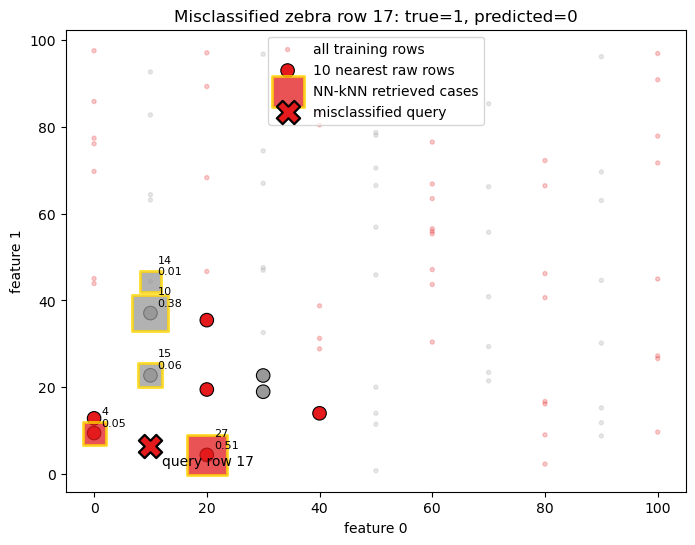

Class probabilities:
p_class_0    0.553
p_class_1    0.447

Nearest raw training points:


,train_row_id,feature_0,feature_1,true_class,raw_distance
0,27,20.0,4.380377,0,10.198300
1,4,0.0,9.417735,0,10.450700
2,8,0.0,12.811363,0,11.888700
3,15,10.0,22.723871,1,16.342100
4,25,20.0,19.463871,0,16.466400
5,35,30.0,18.947136,1,23.619699
6,38,30.0,22.690935,1,25.806801
7,10,10.0,37.079803,1,30.698099
8,21,20.0,35.452599,0,30.742701
9,49,40.0,13.975248,0,30.946100



NN-kNN retrieved/activated cases:


,retrieved_train_position,retrieved_row_id,retrieved_class,activation_mass,retrieved_feature_0,retrieved_feature_1
0,6,27,0,0.5064,20.0,4.380377
1,21,10,1,0.3764,10.0,37.079803
2,67,15,1,0.0637,10.0,22.723871
3,32,4,0,0.0466,0.0,9.417735
4,57,14,1,0.0069,10.0,44.341419


Retrieved class vote totals:


retrieved_class
0    0.553
1    0.447
Name: activation_mass, dtype: float32

In [9]:
import matplotlib.pyplot as plt

zebra_validation_only = zebra_all[zebra_all["predicted_class"].notna()].copy()
zebra_misses = zebra_validation_only[zebra_validation_only["correct"] == False].copy()

print(f"Validation rows: {len(zebra_validation_only)}")
print(f"Misclassified rows: {len(zebra_misses)}")
display(zebra_misses)

train_rows = zebra_result["train_idx"].detach().cpu().numpy()
train_raw = zebra_result["X_train_raw"].detach().cpu().numpy()
train_labels = zebra_result["y_train"].detach().cpu().numpy()
val_rows = zebra_result["val_idx"].detach().cpu().numpy()
val_raw = zebra_result["X_val_raw"].detach().cpu().numpy()
retrieved_cases = zebra_result.get("most_activated_cases")
retrieved_class_ids = zebra_result.get("most_activated_class_ids")
retrieved_activations = zebra_result.get("most_activated_activations")

if retrieved_cases is not None:
    retrieved_cases = retrieved_cases.detach().cpu().numpy()
    retrieved_class_ids = retrieved_class_ids.detach().cpu().numpy()
    retrieved_activations = retrieved_activations.detach().cpu().numpy()

def build_retrieved_table(val_position):
    if retrieved_cases is None:
        return pd.DataFrame()
    retrieved_for_query = retrieved_cases[val_position]
    if np.issubdtype(retrieved_for_query.dtype, np.integer):
        retrieved_positions = retrieved_for_query.astype(int)
        retrieved_row_ids = train_rows[retrieved_positions]
        retrieved_features = train_raw[retrieved_positions]
    else:
        retrieved_features = retrieved_for_query.reshape(retrieved_for_query.shape[0], -1)
        nearest_matches = np.argmin(
            np.linalg.norm(train_raw[:, None, :] - retrieved_features[None, :, :], axis=2),
            axis=0,
        )
        retrieved_positions = nearest_matches.astype(int)
        retrieved_row_ids = train_rows[retrieved_positions]

    return pd.DataFrame(
        {
            "retrieved_train_position": retrieved_positions,
            "retrieved_row_id": retrieved_row_ids,
            "retrieved_class": retrieved_class_ids[val_position],
            "activation_mass": retrieved_activations[val_position].round(4),
            "retrieved_feature_0": retrieved_features[:, 0],
            "retrieved_feature_1": retrieved_features[:, 1],
        }
    )

for _, miss in zebra_misses.iterrows():
    row_id = int(miss["row_id"])
    val_position = int(np.where(val_rows == row_id)[0][0])
    query = val_raw[val_position]
    distances = np.linalg.norm(train_raw - query, axis=1)
    nearest_positions = np.argsort(distances)[:10]
    nearest = pd.DataFrame(
        {
            "train_row_id": train_rows[nearest_positions],
            "feature_0": train_raw[nearest_positions, 0],
            "feature_1": train_raw[nearest_positions, 1],
            "true_class": train_labels[nearest_positions],
            "raw_distance": distances[nearest_positions].round(4),
        }
    )
    retrieved = build_retrieved_table(val_position)

    prob_columns = [column for column in zebra_all.columns if column.startswith("p_class_")]
    probabilities = miss[prob_columns].astype(float).sort_values(ascending=False)
    margin = probabilities.iloc[0] - probabilities.iloc[1] if len(probabilities) > 1 else np.nan
    true_class = int(miss["true_class"])
    predicted_class = int(miss["predicted_class"])

    print("\n" + "=" * 80)
    print(
        f"row_id={row_id} | features=({miss['feature_0']:.3f}, {miss['feature_1']:.3f}) | "
        f"true={true_class} | predicted={predicted_class} | "
        f"confidence={miss['confidence']:.4f} | margin={margin:.4f}"
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        train_raw[:, 0],
        train_raw[:, 1],
        c=train_labels,
        cmap="Set1",
        marker=".",
        alpha=0.22,
        s=35,
        label="all training rows",
    )
    ax.scatter(
        train_raw[nearest_positions, 0],
        train_raw[nearest_positions, 1],
        c=train_labels[nearest_positions],
        cmap="Set1",
        edgecolor="black",
        linewidth=0.8,
        s=95,
        label="10 nearest raw rows",
    )
    if not retrieved.empty:
        activation_sizes = 220 + 1200 * retrieved["activation_mass"].to_numpy(dtype=float)
        ax.scatter(
            retrieved["retrieved_feature_0"],
            retrieved["retrieved_feature_1"],
            c=retrieved["retrieved_class"],
            cmap="Set1",
            marker="s",
            edgecolor="gold",
            linewidth=2.2,
            s=activation_sizes,
            alpha=0.75,
            label="NN-kNN retrieved cases",
        )
        for _, retrieved_row in retrieved.iterrows():
            ax.annotate(
                f"{int(retrieved_row['retrieved_row_id'])}\n{retrieved_row['activation_mass']:.2f}",
                (retrieved_row["retrieved_feature_0"], retrieved_row["retrieved_feature_1"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )
    ax.scatter(
        [query[0]],
        [query[1]],
        marker="X",
        c=[true_class],
        cmap="Set1",
        edgecolor="black",
        linewidth=1.6,
        s=280,
        label="misclassified query",
    )
    ax.annotate(f"query row {row_id}", (query[0], query[1]), xytext=(8, -14), textcoords="offset points")
    ax.set_title(
        f"Misclassified {inspection_dataset} row {row_id}: true={true_class}, predicted={predicted_class}"
    )
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
    ax.legend(loc="best")
    plt.show()

    print("Class probabilities:")
    print(probabilities.to_string())
    print("\nNearest raw training points:")
    display(nearest)

    if not retrieved.empty:
        print("\nNN-kNN retrieved/activated cases:")
        display(retrieved)
        print("Retrieved class vote totals:")
        display(retrieved.groupby("retrieved_class")["activation_mass"].sum().sort_values(ascending=False))

In [15]:
epoch_grid = [20, 30, 40, 50, 60, 75]
baseline_epoch = epoch_grid[0]
epoch_results = {}

for epochs in epoch_grid:
    cfg_epoch = make_classification_cfg(
        {
            **cfg,
            "training_epochs": epochs,
            "checkpoint_path": f"checkpoints/nnknn_{inspection_dataset}_epochs_{epochs}.pth",
        }
    )
    result_epoch = run_single_nnknn_classification_experiment(
        inspection_dataset,
        cfg_epoch,
        run_seed=42,
        split_seed=42,
        checkpoint_label=f"{inspection_dataset}_epochs_{epochs}",
    )
    epoch_results[epochs] = result_epoch

baseline_result = epoch_results[baseline_epoch]
baseline_pred = baseline_result["predictions"].detach().cpu()
baseline_true = baseline_result["y_val"].detach().cpu()
baseline_rows = baseline_result["val_idx"].detach().cpu().numpy()
baseline_miss_positions = (baseline_pred != baseline_true).nonzero(as_tuple=False).flatten().tolist()
baseline_missed_row_ids = [int(baseline_rows[position]) for position in baseline_miss_positions]

print(f"Tracking rows misclassified at baseline epoch {baseline_epoch}:")
print(baseline_missed_row_ids)

tracked_vote_rows = []
for epochs, result_epoch in epoch_results.items():
    probs_epoch = result_epoch["class_probabilities"].detach().cpu()
    pred_epoch = result_epoch["predictions"].detach().cpu()
    true_epoch = result_epoch["y_val"].detach().cpu()
    val_rows_epoch = result_epoch["val_idx"].detach().cpu().numpy()
    confidence_epoch, _ = probs_epoch.max(dim=1)
    retrieved_classes_epoch = result_epoch.get("most_activated_class_ids")
    retrieved_activations_epoch = result_epoch.get("most_activated_activations")

    retrieved_votes_available = retrieved_classes_epoch is not None and retrieved_activations_epoch is not None
    if retrieved_votes_available:
        retrieved_classes_epoch = retrieved_classes_epoch.detach().cpu().numpy()
        retrieved_activations_epoch = retrieved_activations_epoch.detach().cpu().numpy()

    print("\n" + "=" * 88)
    print(f"epochs={epochs} | accuracy={result_epoch['accuracy']:.4f}")

    for row_id in baseline_missed_row_ids:
        matching_positions = np.where(val_rows_epoch == row_id)[0]
        if len(matching_positions) == 0:
            tracked_vote_rows.append(
                {
                    "epochs": epochs,
                    "baseline_epoch": baseline_epoch,
                    "row_id": row_id,
                    "status": "not_in_validation_split",
                }
            )
            continue

        val_position = int(matching_positions[0])
        probability_values = probs_epoch[val_position].numpy()
        probability_margin = np.sort(probability_values)[-1] - np.sort(probability_values)[-2]
        true_class = int(true_epoch[val_position])
        predicted_class = int(pred_epoch[val_position])
        is_correct = predicted_class == true_class

        row = {
            "epochs": epochs,
            "baseline_epoch": baseline_epoch,
            "row_id": row_id,
            "status": "correct_now" if is_correct else "still_misclassified",
            "true_class": true_class,
            "predicted_class": predicted_class,
            "confidence": float(confidence_epoch[val_position]),
            "probability_margin": float(probability_margin),
        }

        if retrieved_votes_available:
            class_votes = (
                pd.DataFrame(
                    {
                        "retrieved_class": retrieved_classes_epoch[val_position],
                        "activation_mass": retrieved_activations_epoch[val_position],
                    }
                )
                .groupby("retrieved_class")["activation_mass"]
                .sum()
                .sort_index()
            )
            row["retrieved_vote_winner"] = int(class_votes.idxmax())
            row["true_class_retrieved_mass"] = float(class_votes.get(true_class, 0.0))
            row["predicted_class_retrieved_mass"] = float(class_votes.get(predicted_class, 0.0))
            for retrieved_class, activation_mass in class_votes.items():
                row[f"retrieved_class_{int(retrieved_class)}_mass"] = float(activation_mass)
        else:
            class_votes = pd.Series(dtype="float32", name="activation_mass")
            row["retrieved_vote_winner"] = np.nan
            row["true_class_retrieved_mass"] = np.nan
            row["predicted_class_retrieved_mass"] = np.nan

        tracked_vote_rows.append(row)

        print(
            f"\nrow_id={row_id} | {row['status']} | true={true_class} | "
            f"predicted={predicted_class} | confidence={row['confidence']:.4f} | "
            f"probability_margin={probability_margin:.4f}"
        )
        print(class_votes)

tracked_epoch_vote_summary = pd.DataFrame(tracked_vote_rows)
print(
    f"Expected tracked rows: {len(baseline_missed_row_ids)} baseline misses "
    f"x {len(epoch_grid)} epochs = {len(baseline_missed_row_ids) * len(epoch_grid)}"
)
print(f"Actual tracked rows: {len(tracked_epoch_vote_summary)}")
display(tracked_epoch_vote_summary.sort_values(["row_id", "epochs"]).reset_index(drop=True))

cases trainable: False
labels trainable: False
Number of feature extractor parameters: 0
Number of glocal weightor parameters: 1
torch.Size([4, 2])
Number of adapter parameters: 0
Number of case_net_params: 3
torch.Size([88])
torch.Size([88])
torch.Size([88, 4])
*****************
Training started for training_epochs epochs with batch size 32

[Stage 1] Retrieval-only training for up to 20 epochs (patience=30)
[Stage1] Epoch 1 - Val Acc: 0.7273 | Val Loss: 1.4829
[Stage1] New best (epoch 1) Val Metric: 0.7273 | Val Loss: 1.4829 — saved: checkpoints/nnknn_zebra_epochs_20_zebra_zebra_epochs_20_retr.pth
[Stage1] Epoch 2 - Val Acc: 0.7273 | Val Loss: 1.4767
[Stage1] New best (epoch 2) Val Metric: 0.7273 | Val Loss: 1.4767 — saved: checkpoints/nnknn_zebra_epochs_20_zebra_zebra_epochs_20_retr.pth
[Stage1] Epoch 3 - Val Acc: 0.6818 | Val Loss: 2.0775
[Stage1] No improv. Best so far: 1.4767 (epoch 2)
[Stage1] Epoch 4 - Val Acc: 0.6818 | Val Loss: 2.0681
[Stage1] No improv. Best so far: 1.4767 (

,epochs,baseline_epoch,row_id,status,true_class,predicted_class,confidence,probability_margin,retrieved_vote_winner,true_class_retrieved_mass,predicted_class_retrieved_mass,retrieved_class_0_mass,retrieved_class_1_mass
0,20,20,17,still_misclassified,1,0,0.999758,0.999517,0,0.000242,0.999758,0.999758,0.000242
1,30,20,17,still_misclassified,1,0,0.999321,0.998642,0,0.000679,0.999321,0.999321,0.000679
2,40,20,17,still_misclassified,1,0,0.972685,0.945370,0,0.027315,0.972685,0.972685,0.027315
3,50,20,17,still_misclassified,1,0,0.875500,0.751001,0,0.124500,0.875500,0.875500,0.124500
4,60,20,17,still_misclassified,1,0,0.714897,0.429794,0,0.285103,0.714897,0.714897,0.285103
5,75,20,17,correct_now,1,1,0.507876,0.015752,1,0.507876,0.507876,0.492124,0.507876
6,20,20,24,still_misclassified,0,1,0.754670,0.509339,1,0.245330,0.754669,0.245330,0.754669
7,30,20,24,correct_now,0,0,0.734946,0.469892,0,0.734946,0.734946,0.734946,0.265054
8,40,20,24,correct_now,0,0,0.886078,0.772156,0,0.886078,0.886078,0.886078,0.113922
9,50,20,24,correct_now,0,0,0.983162,0.966325,0,0.983162,0.983162,0.983162,0.016838


## Epoch failure visualiations

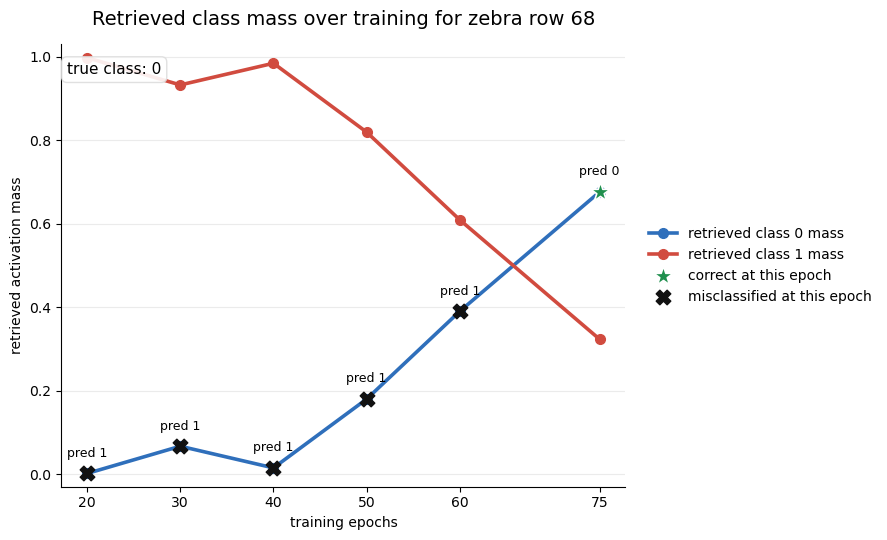

,epochs,status,true_class,predicted_class,confidence,probability_margin,retrieved_class_0_mass,retrieved_class_1_mass
4,20,still_misclassified,0,1,0.998281,0.996562,0.001719,0.998281
10,30,still_misclassified,0,1,0.932943,0.865887,0.067057,0.932943
16,40,still_misclassified,0,1,0.984895,0.969789,0.015105,0.984895
22,50,still_misclassified,0,1,0.819805,0.639610,0.180195,0.819805
28,60,still_misclassified,0,1,0.609317,0.218635,0.390683,0.609317
34,75,correct_now,0,0,0.676771,0.353543,0.676771,0.323229


In [35]:
plot_row_id = 68
row_trace = (
    tracked_epoch_vote_summary[tracked_epoch_vote_summary["row_id"] == plot_row_id]
    .sort_values("epochs")
    .copy()
)

if row_trace.empty:
    raise ValueError(f"row_id {plot_row_id} was not tracked. Check baseline_missed_row_ids above.")

mass_columns = sorted(
    [column for column in row_trace.columns if column.startswith("retrieved_class_") and column.endswith("_mass")],
    key=lambda column: int(column.split("_")[2]),
)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {0: "#2f6fbb", 1: "#d14b3f"}

for column in mass_columns:
    class_id = int(column.split("_")[2])
    label = f"retrieved class {class_id} mass"
    ax.plot(
        row_trace["epochs"],
        row_trace[column],
        marker="o",
        linewidth=2.6,
        markersize=7,
        color=colors.get(class_id),
        label=label,
    )

correct_mask = row_trace["status"] == "correct_now"
ax.scatter(
    row_trace.loc[correct_mask, "epochs"],
    row_trace.loc[correct_mask, "true_class_retrieved_mass"],
    marker="*",
    s=220,
    color="#1f8f4d",
    edgecolor="white",
    linewidth=1.2,
    zorder=5,
    label="correct at this epoch",
)
ax.scatter(
    row_trace.loc[~correct_mask, "epochs"],
    row_trace.loc[~correct_mask, "true_class_retrieved_mass"],
    marker="X",
    s=110,
    color="#111111",
    zorder=5,
    label="misclassified at this epoch",
)

for _, row in row_trace.iterrows():
    ax.annotate(
        f"pred {int(row['predicted_class'])}",
        (row["epochs"], row["true_class_retrieved_mass"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

true_class = int(row_trace["true_class"].dropna().iloc[0])
ax.set_title(f"Retrieved class mass over training for zebra row {plot_row_id}", fontsize=14, pad=14)
ax.set_xlabel("training epochs")
ax.set_ylabel("retrieved activation mass")
ax.set_ylim(-0.03, 1.03)
ax.set_xticks(row_trace["epochs"])
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(
    0.01,
    0.96,
    f"true class: {true_class}",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#dddddd", "alpha": 0.9},
)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

display(row_trace[["epochs", "status", "true_class", "predicted_class", "confidence", "probability_margin"] + mass_columns])

Comparing row 68: early epoch 20 vs comparison epoch 75

epochs=20 | still_misclassified | true=0 | predicted=1
retrieved_class
0    0.0018
1    0.9983
Name: activation_mass, dtype: float32

epochs=75 | correct_now | true=0 | predicted=0
retrieved_class
0    0.6768
1    0.3232
Name: activation_mass, dtype: float32


,epochs,status,true_class,predicted_class,confidence,probability_margin,true_class_retrieved_mass,predicted_class_retrieved_mass
0,20,still_misclassified,0,1,0.998281,0.996562,0.0018,0.9983
1,75,correct_now,0,0,0.676771,0.353543,0.6768,0.6768



Diagnosis:
At the early epoch, retrieved activation mass leans toward the predicted class instead of the true class.
True-class retrieved mass rises from 0.002 to 0.677.
Predicted-class retrieved mass falls from 0.998 to 0.677.


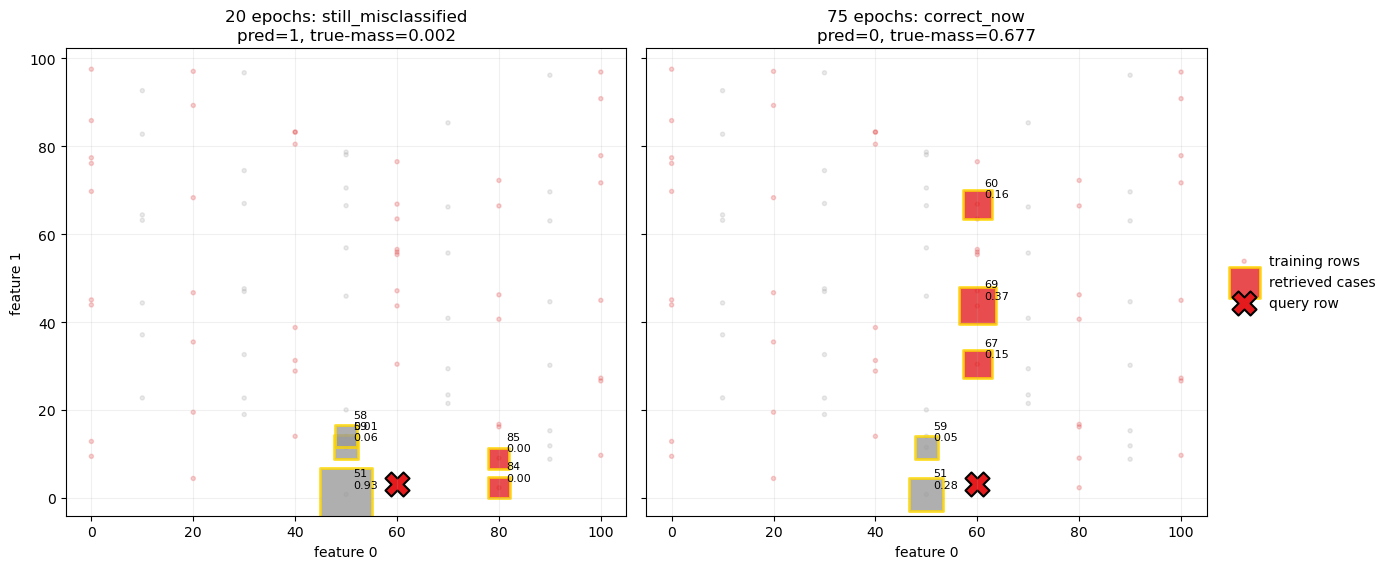

,retrieved_train_position,retrieved_row_id,retrieved_class,activation_mass,retrieved_feature_0,retrieved_feature_1,training_true_class,epoch
0,75,51,1,0.9300,50.0,0.736227,1,20
1,10,59,1,0.0568,50.0,11.453008,1,20
2,37,58,1,0.0115,50.0,13.979700,1,20
3,85,84,0,0.0012,80.0,2.271207,0,20
4,51,85,0,0.0006,80.0,9.004786,0,20


,retrieved_train_position,retrieved_row_id,retrieved_class,activation_mass,retrieved_feature_0,retrieved_feature_1,training_true_class,epoch
0,0,69,0,0.3675,60.0,43.671738,0,75
1,75,51,1,0.2778,50.0,0.736227,1,75
2,50,60,0,0.1615,60.0,66.840294,0,75
3,55,67,0,0.1478,60.0,30.395010,0,75
4,10,59,1,0.0454,50.0,11.453008,1,75


In [36]:
diagnostic_row_id = plot_row_id
early_epoch = baseline_epoch

row_trace = (
    tracked_epoch_vote_summary[tracked_epoch_vote_summary["row_id"] == diagnostic_row_id]
    .sort_values("epochs")
    .copy()
)
if row_trace.empty:
    raise ValueError(f"row_id {diagnostic_row_id} was not tracked.")

correct_epochs = row_trace.loc[row_trace["status"] == "correct_now", "epochs"]
comparison_epoch = int(correct_epochs.iloc[0]) if len(correct_epochs) else int(row_trace["epochs"].iloc[-1])
print(f"Comparing row {diagnostic_row_id}: early epoch {early_epoch} vs comparison epoch {comparison_epoch}")


def retrieved_table_for_epoch(result_epoch, row_id):
    train_rows_epoch = result_epoch["train_idx"].detach().cpu().numpy()
    train_raw_epoch = result_epoch["X_train_raw"].detach().cpu().numpy()
    train_labels_epoch = result_epoch["y_train"].detach().cpu().numpy()
    val_rows_epoch = result_epoch["val_idx"].detach().cpu().numpy()
    val_raw_epoch = result_epoch["X_val_raw"].detach().cpu().numpy()
    val_position = int(np.where(val_rows_epoch == row_id)[0][0])
    query = val_raw_epoch[val_position]

    retrieved_cases_epoch = result_epoch.get("most_activated_cases")
    retrieved_classes_epoch = result_epoch.get("most_activated_class_ids")
    retrieved_activations_epoch = result_epoch.get("most_activated_activations")
    if retrieved_cases_epoch is None or retrieved_classes_epoch is None or retrieved_activations_epoch is None:
        return pd.DataFrame(), pd.Series(dtype="float32", name="activation_mass"), query, val_position

    retrieved_cases_epoch = retrieved_cases_epoch.detach().cpu().numpy()
    retrieved_classes_epoch = retrieved_classes_epoch.detach().cpu().numpy()
    retrieved_activations_epoch = retrieved_activations_epoch.detach().cpu().numpy()
    retrieved_for_query = retrieved_cases_epoch[val_position]

    if np.issubdtype(retrieved_for_query.dtype, np.integer):
        retrieved_positions = retrieved_for_query.astype(int)
        retrieved_row_ids = train_rows_epoch[retrieved_positions]
        retrieved_features = train_raw_epoch[retrieved_positions]
    else:
        retrieved_features = retrieved_for_query.reshape(retrieved_for_query.shape[0], -1)
        nearest_matches = np.argmin(
            np.linalg.norm(train_raw_epoch[:, None, :] - retrieved_features[None, :, :], axis=2),
            axis=0,
        )
        retrieved_positions = nearest_matches.astype(int)
        retrieved_row_ids = train_rows_epoch[retrieved_positions]

    retrieved = pd.DataFrame(
        {
            "retrieved_train_position": retrieved_positions,
            "retrieved_row_id": retrieved_row_ids,
            "retrieved_class": retrieved_classes_epoch[val_position],
            "activation_mass": retrieved_activations_epoch[val_position].round(4),
            "retrieved_feature_0": retrieved_features[:, 0],
            "retrieved_feature_1": retrieved_features[:, 1],
            "training_true_class": train_labels_epoch[retrieved_positions],
        }
    )
    class_votes = retrieved.groupby("retrieved_class")["activation_mass"].sum().sort_index()
    return retrieved, class_votes, query, val_position


def summary_for_epoch(result_epoch, row_id, epoch):
    pred_epoch = result_epoch["predictions"].detach().cpu()
    true_epoch = result_epoch["y_val"].detach().cpu()
    probs_epoch = result_epoch["class_probabilities"].detach().cpu()
    val_rows_epoch = result_epoch["val_idx"].detach().cpu().numpy()
    val_position = int(np.where(val_rows_epoch == row_id)[0][0])
    probability_values = probs_epoch[val_position].numpy()
    true_class = int(true_epoch[val_position])
    predicted_class = int(pred_epoch[val_position])
    retrieved, class_votes, query, _ = retrieved_table_for_epoch(result_epoch, row_id)
    return {
        "epochs": epoch,
        "status": "correct_now" if true_class == predicted_class else "still_misclassified",
        "true_class": true_class,
        "predicted_class": predicted_class,
        "confidence": float(probability_values.max()),
        "probability_margin": float(np.sort(probability_values)[-1] - np.sort(probability_values)[-2]),
        "true_class_retrieved_mass": float(class_votes.get(true_class, 0.0)),
        "predicted_class_retrieved_mass": float(class_votes.get(predicted_class, 0.0)),
    }, retrieved, class_votes, query

comparison_rows = []
retrieved_by_epoch = {}
query_by_epoch = {}
for epoch in [early_epoch, comparison_epoch]:
    summary_row, retrieved, class_votes, query = summary_for_epoch(epoch_results[epoch], diagnostic_row_id, epoch)
    comparison_rows.append(summary_row)
    retrieved_by_epoch[epoch] = retrieved
    query_by_epoch[epoch] = query
    print("\n" + "=" * 80)
    print(f"epochs={epoch} | {summary_row['status']} | true={summary_row['true_class']} | predicted={summary_row['predicted_class']}")
    print(class_votes)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

true_class = int(comparison_df["true_class"].iloc[0])
early_true_mass = comparison_df.loc[comparison_df["epochs"] == early_epoch, "true_class_retrieved_mass"].iloc[0]
later_true_mass = comparison_df.loc[comparison_df["epochs"] == comparison_epoch, "true_class_retrieved_mass"].iloc[0]
early_pred_mass = comparison_df.loc[comparison_df["epochs"] == early_epoch, "predicted_class_retrieved_mass"].iloc[0]
later_pred_mass = comparison_df.loc[comparison_df["epochs"] == comparison_epoch, "predicted_class_retrieved_mass"].iloc[0]

print("\nDiagnosis:")
if early_true_mass < early_pred_mass:
    print("At the early epoch, retrieved activation mass leans toward the predicted class instead of the true class.")
else:
    print("At the early epoch, retrieved mass already favors the true class; the remaining error is likely from probability aggregation or a very small margin.")
if later_true_mass > early_true_mass:
    print(f"True-class retrieved mass rises from {early_true_mass:.3f} to {later_true_mass:.3f}.")
if later_pred_mass < early_pred_mass:
    print(f"Predicted-class retrieved mass falls from {early_pred_mass:.3f} to {later_pred_mass:.3f}.")

train_raw_reference = epoch_results[early_epoch]["X_train_raw"].detach().cpu().numpy()
train_labels_reference = epoch_results[early_epoch]["y_train"].detach().cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharex=True, sharey=True)
colors = {0: "#2f6fbb", 1: "#d14b3f"}

for ax, epoch in zip(axes, [early_epoch, comparison_epoch]):
    retrieved = retrieved_by_epoch[epoch]
    query = query_by_epoch[epoch]
    summary_row = comparison_df[comparison_df["epochs"] == epoch].iloc[0]
    ax.scatter(
        train_raw_reference[:, 0],
        train_raw_reference[:, 1],
        c=train_labels_reference,
        cmap="Set1",
        marker=".",
        alpha=0.20,
        s=35,
        label="training rows",
    )
    if not retrieved.empty:
        sizes = 230 + 1300 * retrieved["activation_mass"].to_numpy(dtype=float)
        ax.scatter(
            retrieved["retrieved_feature_0"],
            retrieved["retrieved_feature_1"],
            c=retrieved["retrieved_class"],
            cmap="Set1",
            marker="s",
            edgecolor="gold",
            linewidth=2.1,
            s=sizes,
            alpha=0.78,
            label="retrieved cases",
        )
        for _, retrieved_row in retrieved.iterrows():
            ax.annotate(
                f"{int(retrieved_row['retrieved_row_id'])}\n{retrieved_row['activation_mass']:.2f}",
                (retrieved_row["retrieved_feature_0"], retrieved_row["retrieved_feature_1"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )
    ax.scatter(
        [query[0]],
        [query[1]],
        marker="X",
        c=[true_class],
        cmap="Set1",
        edgecolor="black",
        linewidth=1.5,
        s=300,
        label="query row",
    )
    ax.set_title(
        f"{epoch} epochs: {summary_row['status']}\n"
        f"pred={int(summary_row['predicted_class'])}, true-mass={summary_row['true_class_retrieved_mass']:.3f}",
        fontsize=12,
    )
    ax.set_xlabel("feature 0")
    ax.grid(alpha=0.18)

axes[0].set_ylabel("feature 1")
axes[1].legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

display(retrieved_by_epoch[early_epoch].assign(epoch=early_epoch))
display(retrieved_by_epoch[comparison_epoch].assign(epoch=comparison_epoch))